In [1]:
from keras.layers import Input, Dense
from keras.models import Model, Sequential
from keras import regularizers
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.manifold import TSNE
from sklearn import preprocessing 
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns

In [2]:
from keras.models import Model, load_model
from keras.layers import Input,Dense, BatchNormalization #layers of autoencoder
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping #callbacks
from keras import regularizers #regularization
import keras
import sklearn.metrics as metrics #metrics librry

In [3]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 15488395232928014086
 xla_global_id: -1]

In [4]:
def printandwrite(loc, text, firstLine = False):       
    print(text)
    if firstLine:
        sourceFile = open(loc, 'w')
    else:
        sourceFile = open(loc, 'a')
    sourceFile.write(text)
    sourceFile.close()

# Load Dataset

In [5]:
load_Folder = "./Datasets/WGN/"

## Real normal

In [6]:
alpha_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_25_MP.npy", allow_pickle=True)
alpha_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_20_MP.npy", allow_pickle=True)
alpha_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_15_MP.npy", allow_pickle=True)

## Real Anomalous

In [11]:
alpha_sub_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_25_MP.npy", allow_pickle=True)
alpha_sub_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_20_MP.npy", allow_pickle=True)
alpha_sub_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_15_MP.npy", allow_pickle=True)

# To compare the similarity using euclidean distance, we need the signal data to be the same lenght. As such, we will remove access information at the end as we assume we have knowledge of the length of time the benign program will take.

In [16]:
def cutToLength(dataset, length):
    new_Dataset = np.zeros((dataset.shape[0],length))
    
    for i in range(dataset.shape[0]):
        temp = dataset[i]
        new_Dataset[i] = temp[:length]
    
    new_Dataset = np.array(new_Dataset)
    return new_Dataset

# alpha

In [17]:
print(alpha_SNR_30.shape)

(3000, 12)


In [18]:
print(alpha_sub_SNR_25.shape)
print(alpha_sub_SNR_20.shape)
print(alpha_sub_SNR_15.shape)

(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)


In [19]:
alpha_sub_SNR_25 = cutToLength(alpha_sub_SNR_25, 12)
alpha_sub_SNR_20 = cutToLength(alpha_sub_SNR_20, 12)
alpha_sub_SNR_15 = cutToLength(alpha_sub_SNR_15, 12)
print(alpha_SNR_20.shape)
print(alpha_sub_SNR_20.shape)

(3000, 12)
(1312, 12)


# Method to do anomaly detection

In [32]:
import sys
# setting path
sys.path.append('../../')
from Modules.Tests import KNN_Exp

# alpha

# Settings

In [33]:
program_N = alpha_SNR_15
program_A = alpha_sub_SNR_15
SNR = "15"

folder = "./Results/kNN/Alpha_SNR_" + SNR + "/"

NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

Beginning Tests...


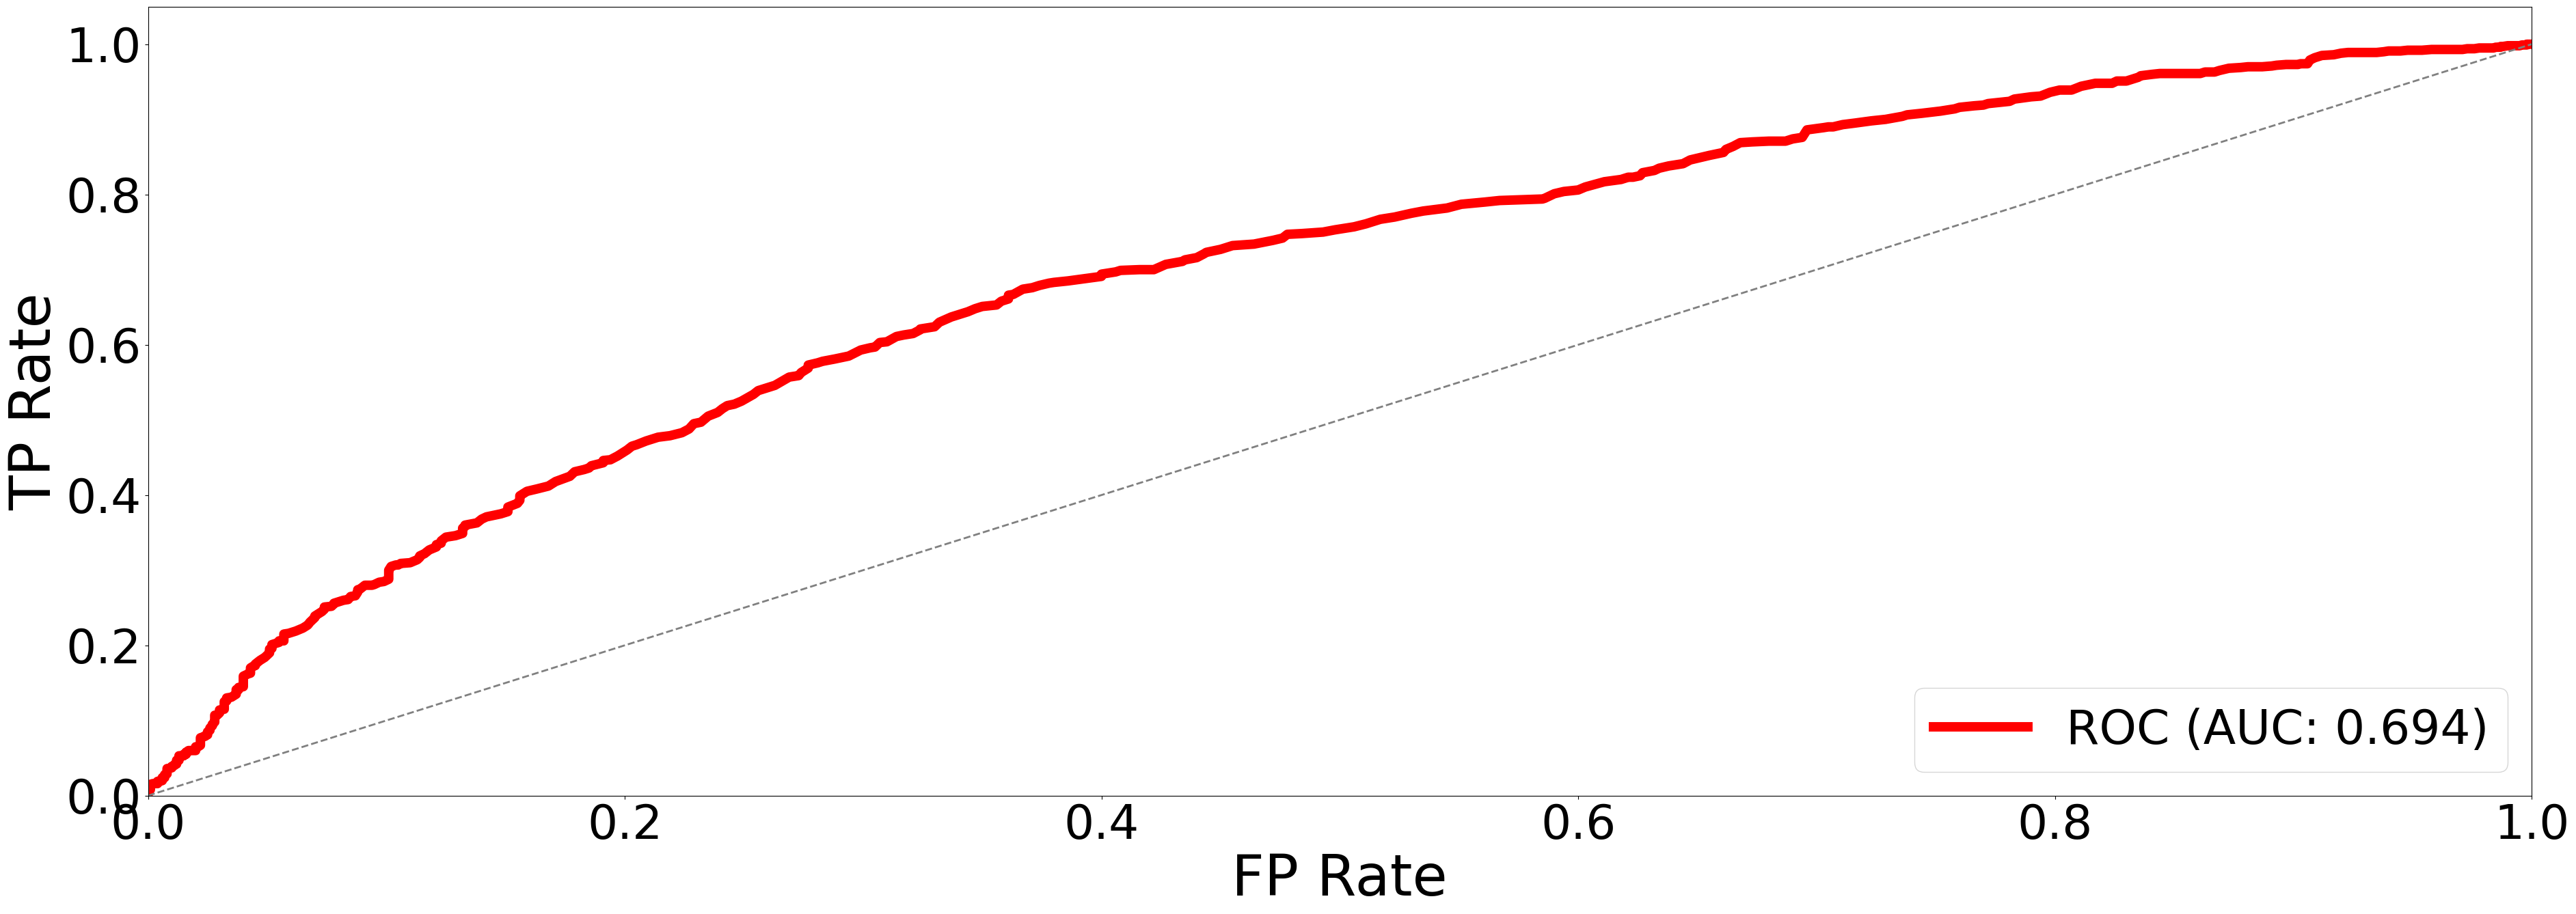

Method: KNN
Normal Dataset Used: alpha SNR-15 TS-2000
Size of Training Set: 2000
Test Set Used: alpha SNR-15 normal along with alpha_sub SNR-15 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.686289697908598
Max f1 score: 0.686289697908598
Min f1 score: 0.686289697908598
Avg acc score: 0.6535
Max acc score: 0.6535
Min acc score: 0.6535
Avg AUC score: 0.694002
Max AUC score: 0.694002
Min AUC score: 0.694002
Avg Precision score: 0.6474543707973103
Max Precision score: 0.6474543707973103
Min Precision score: 0.6474543707973103
Avg Recall score: 0.674
Max Recall score: 0.674
Min Recall score: 0.674
Time: 16.445945299929008


In [34]:
Training_Amount = 2000

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


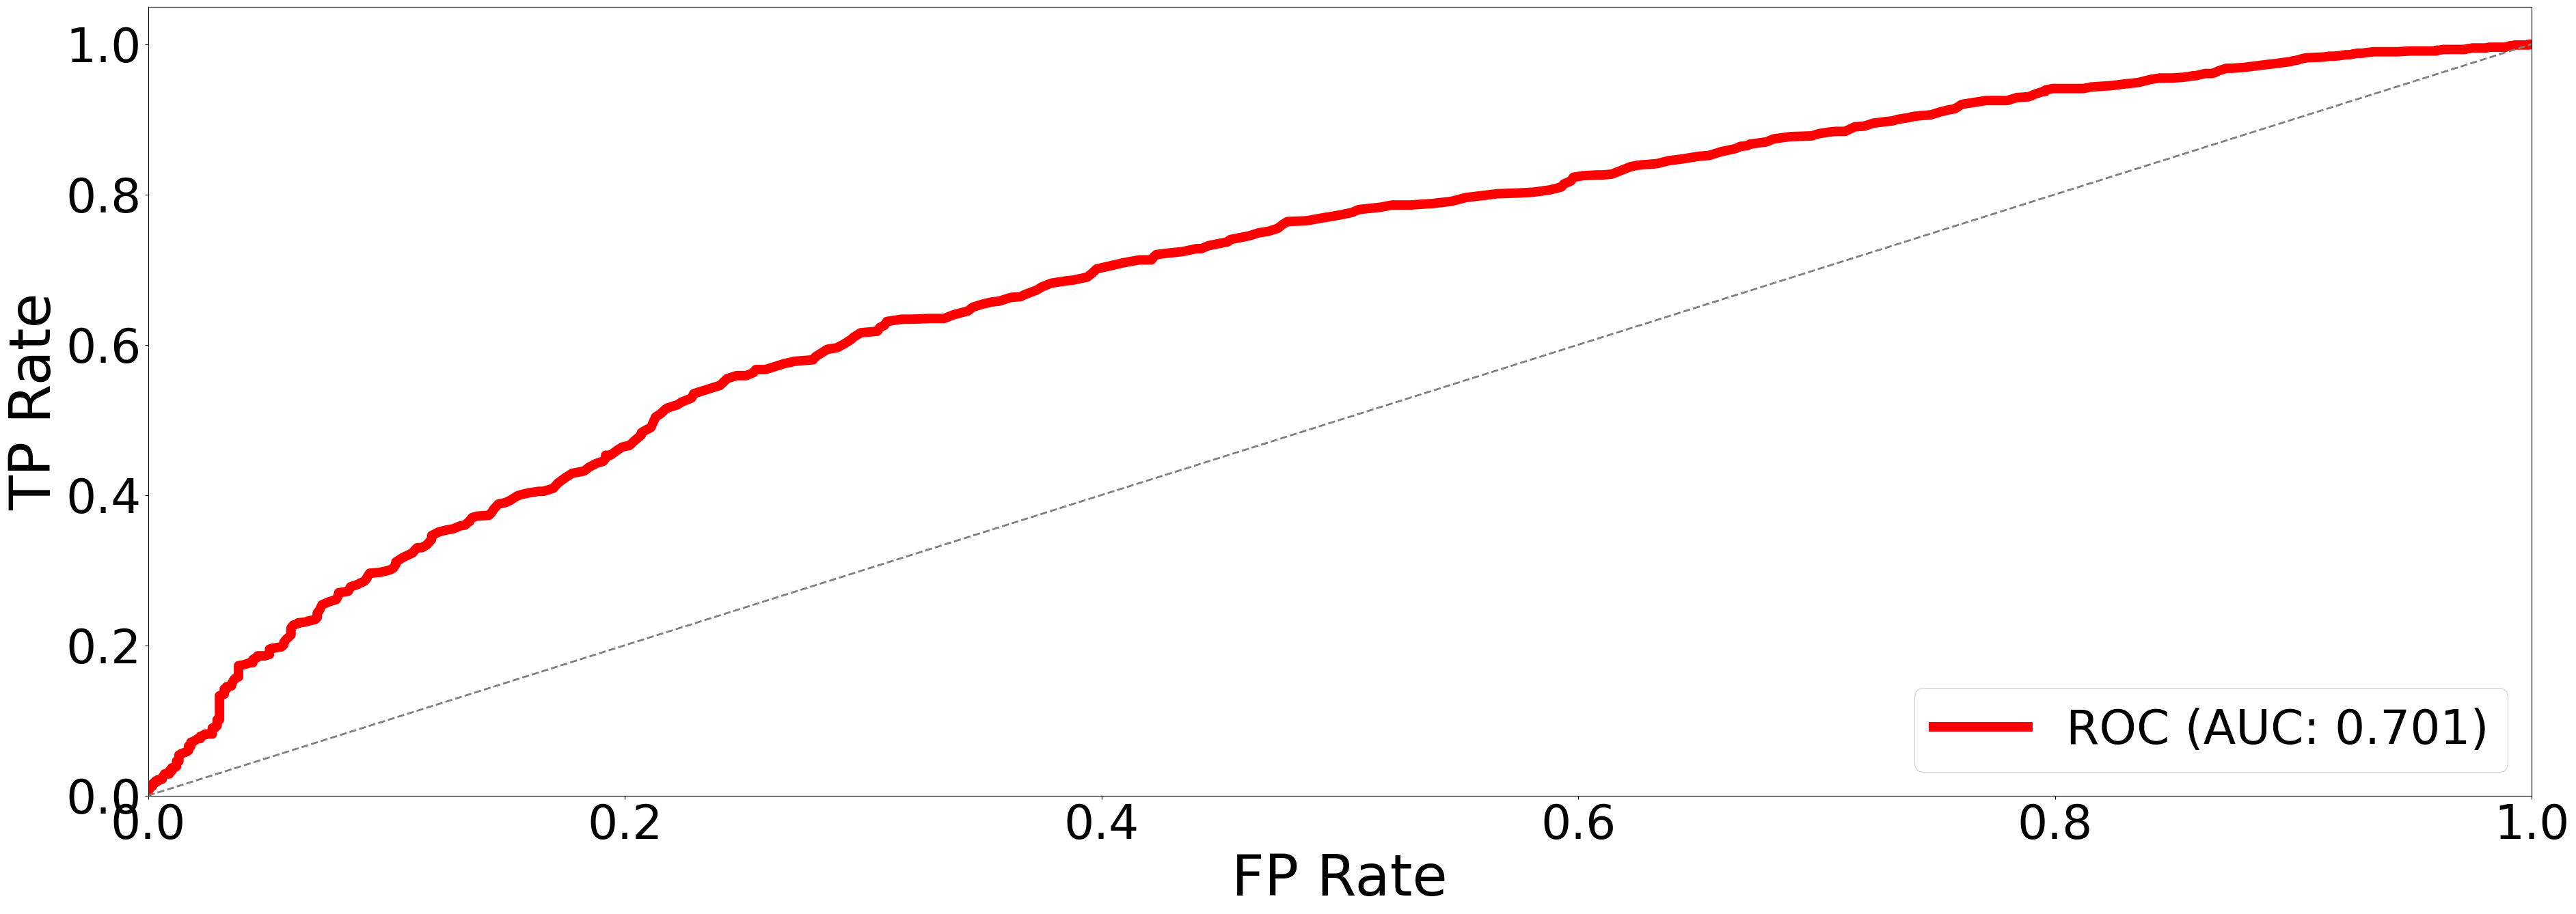

Method: KNN
Normal Dataset Used: alpha SNR-15 TS-1500
Size of Training Set: 1500
Test Set Used: alpha SNR-15 normal along with alpha_sub SNR-15 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.6868613138686132
Max f1 score: 0.6868613138686132
Min f1 score: 0.6868613138686132
Avg acc score: 0.6605
Max acc score: 0.6605
Min acc score: 0.6605
Avg AUC score: 0.7008040000000001
Max AUC score: 0.7008040000000001
Min AUC score: 0.7008040000000001
Avg Precision score: 0.6705632306057385
Max Precision score: 0.6705632306057385
Min Precision score: 0.6705632306057385
Avg Recall score: 0.631
Max Recall score: 0.631
Min Recall score: 0.631
Time: 15.30554770003073


In [36]:
Training_Amount = 1500

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


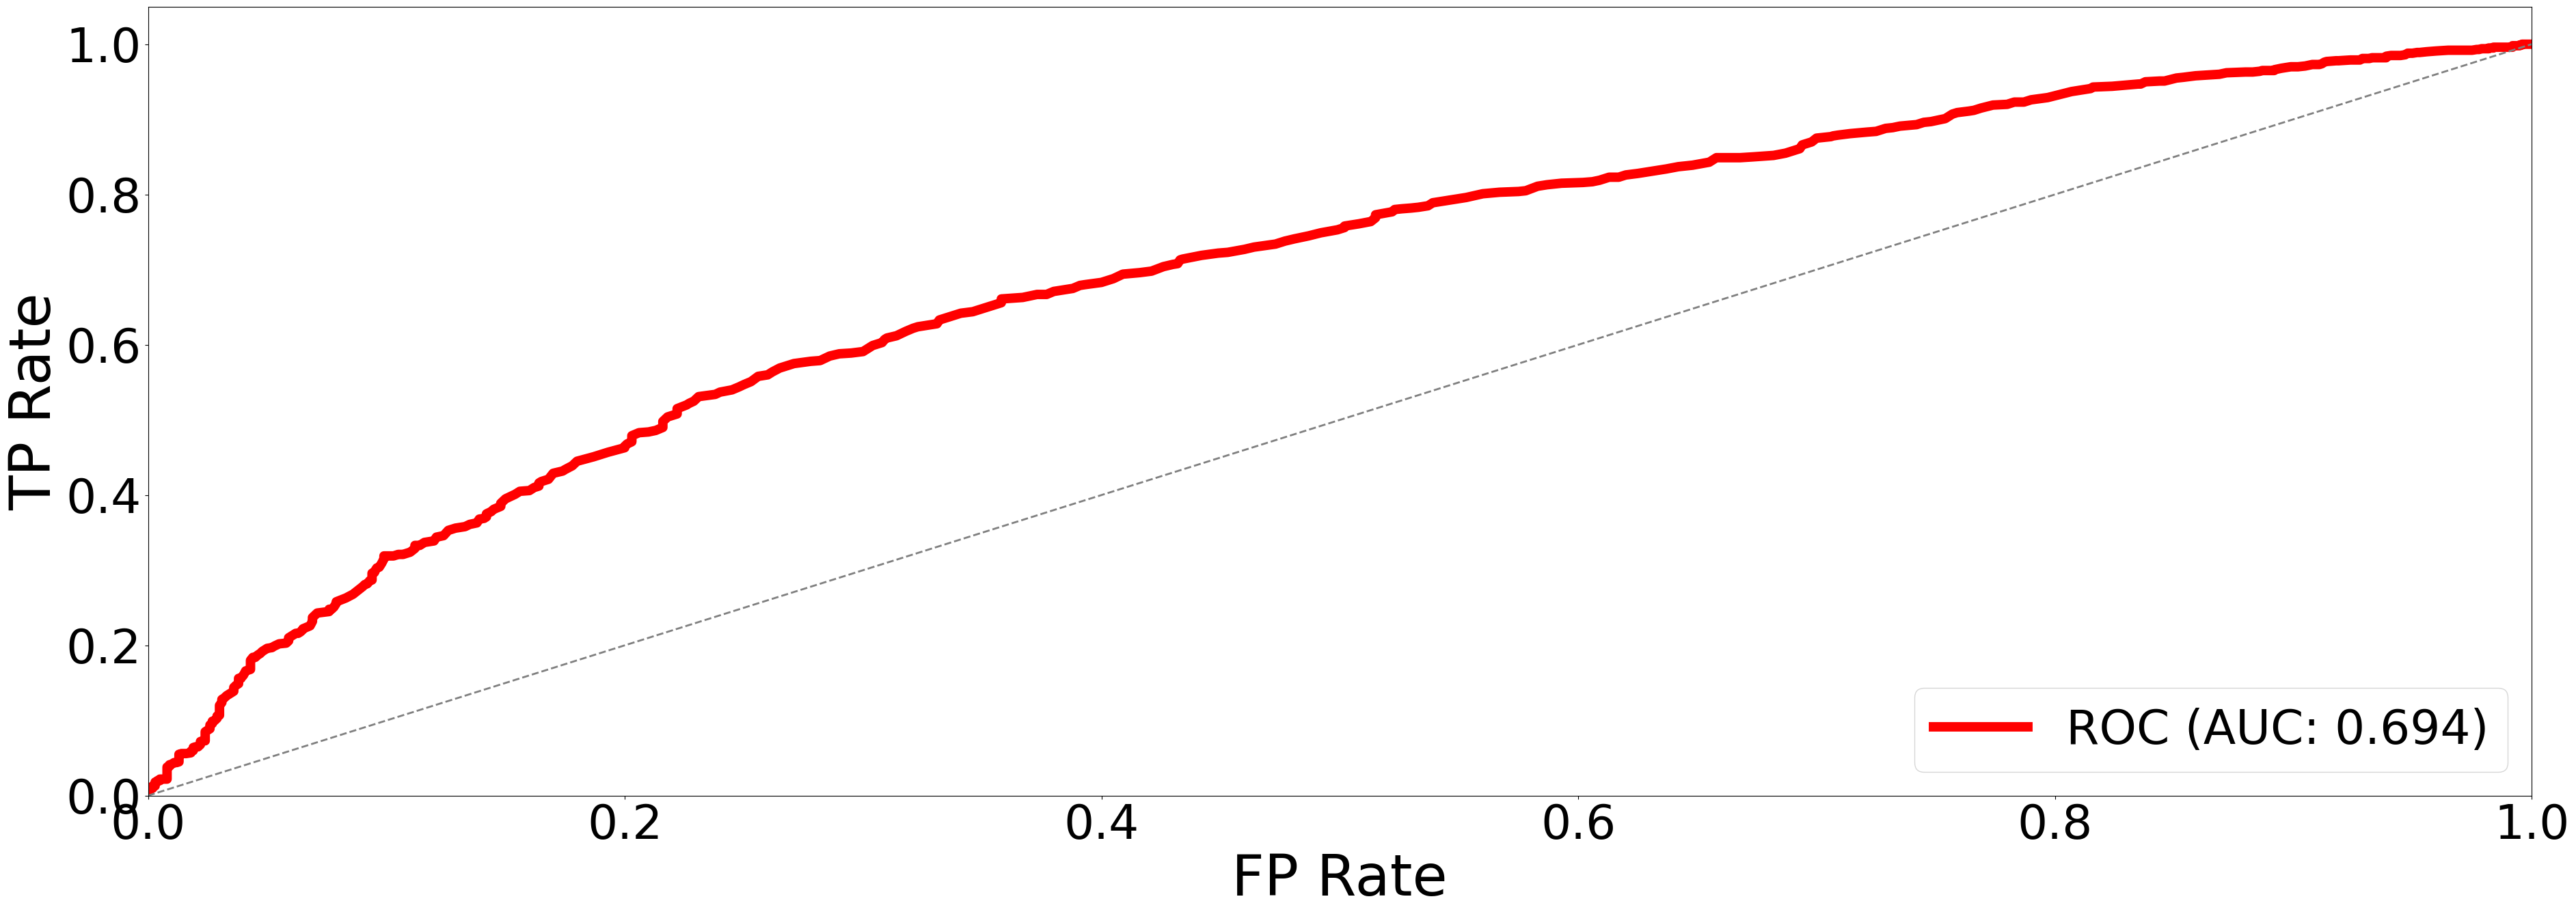

Method: KNN
Normal Dataset Used: alpha SNR-15 TS-1000
Size of Training Set: 1000
Test Set Used: alpha SNR-15 normal along with alpha_sub SNR-15 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.6835810076114535
Max f1 score: 0.6835810076114535
Min f1 score: 0.6835810076114535
Avg acc score: 0.652
Max acc score: 0.652
Min acc score: 0.652
Avg AUC score: 0.6944615
Max AUC score: 0.6944615
Min AUC score: 0.6944615
Avg Precision score: 0.6822541966426858
Max Precision score: 0.6822541966426858
Min Precision score: 0.6822541966426858
Avg Recall score: 0.575
Max Recall score: 0.575
Min Recall score: 0.575
Time: 15.629683299921453


In [37]:
Training_Amount = 1000

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


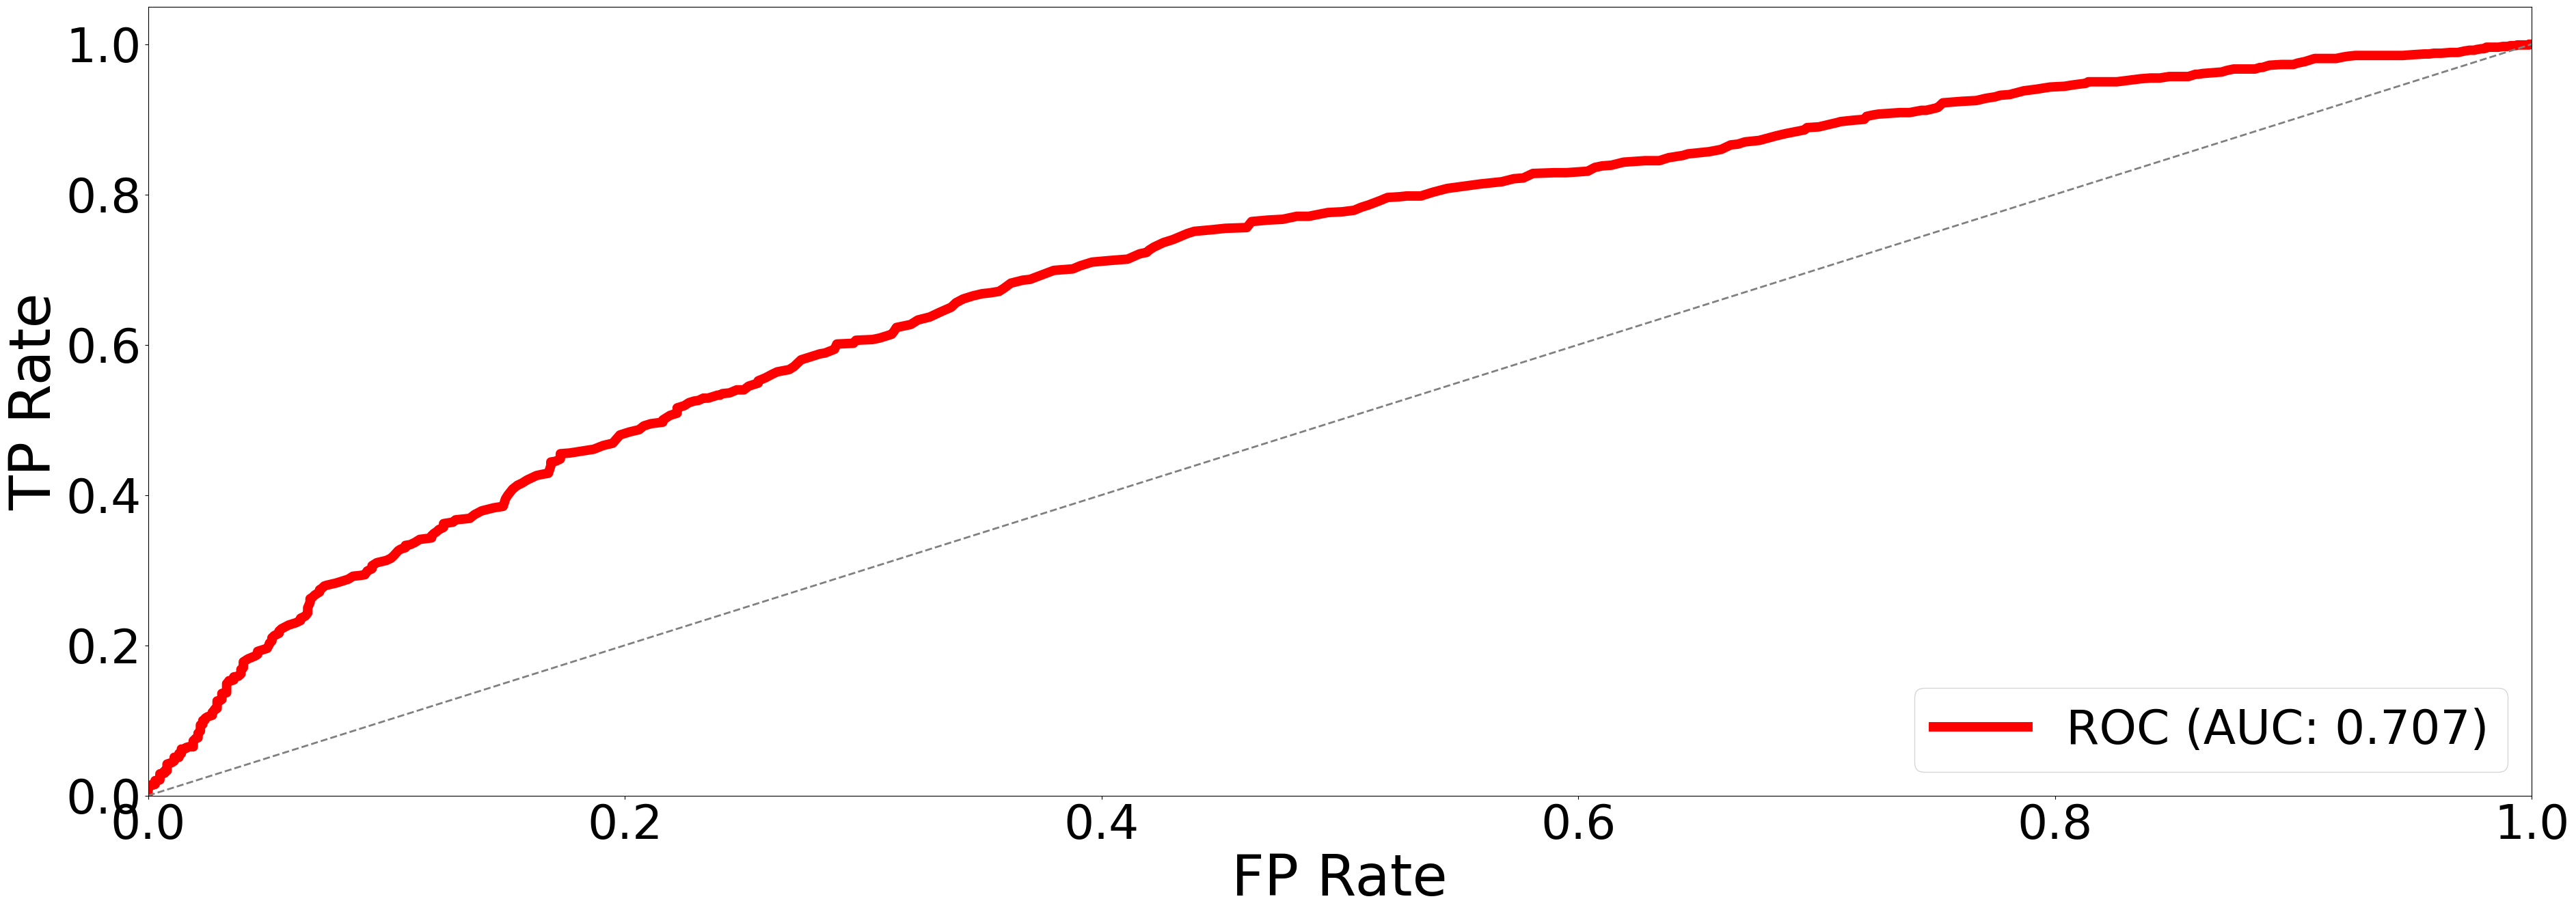

Method: KNN
Normal Dataset Used: alpha SNR-15 TS-500
Size of Training Set: 500
Test Set Used: alpha SNR-15 normal along with alpha_sub SNR-15 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.6893457943925234
Max f1 score: 0.6893457943925234
Min f1 score: 0.6893457943925234
Avg acc score: 0.66
Max acc score: 0.66
Min acc score: 0.66
Avg AUC score: 0.7073805
Max AUC score: 0.7073805
Min AUC score: 0.7073805
Avg Precision score: 0.6532567049808429
Max Precision score: 0.6532567049808429
Min Precision score: 0.6532567049808429
Avg Recall score: 0.682
Max Recall score: 0.682
Min Recall score: 0.682
Time: 16.310451600002125


In [38]:
Training_Amount = 500

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


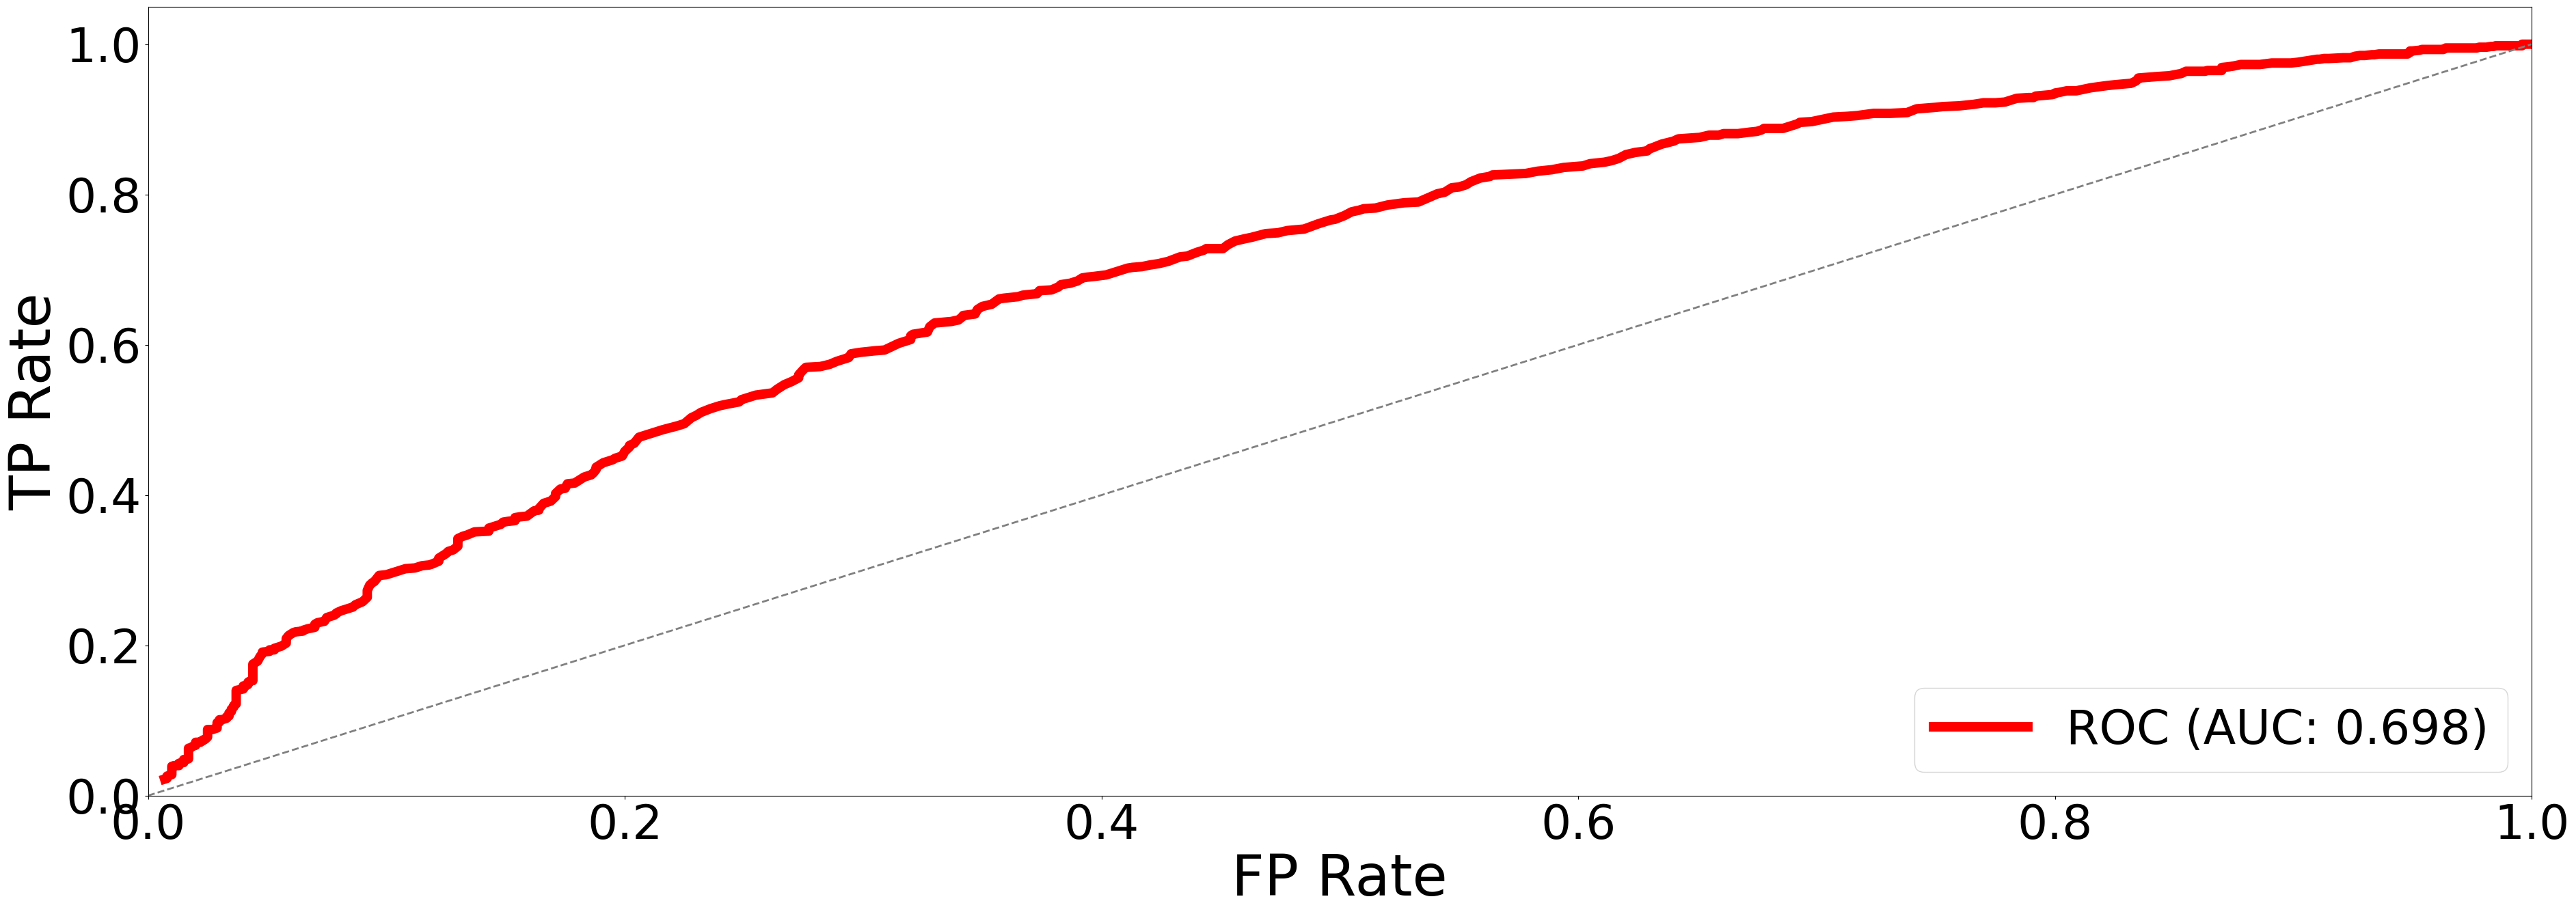

Method: KNN
Normal Dataset Used: alpha SNR-15 TS-100
Size of Training Set: 100
Test Set Used: alpha SNR-15 normal along with alpha_sub SNR-15 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.6947535771065183
Max f1 score: 0.6947535771065183
Min f1 score: 0.6947535771065183
Avg acc score: 0.652
Max acc score: 0.652
Min acc score: 0.652
Avg AUC score: 0.697508
Max AUC score: 0.697508
Min AUC score: 0.697508
Avg Precision score: 0.6493123772102161
Max Precision score: 0.6493123772102161
Min Precision score: 0.6493123772102161
Avg Recall score: 0.661
Max Recall score: 0.661
Min Recall score: 0.661
Time: 15.646585300099105


In [39]:
Training_Amount = 100

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)